# MLB-B9G2-06 · Implementation orchestration and comparison

Created by Kaveesha Tennakoon.
Run preprocessing → six model notebooks → this comparison. `python run_all.py` executes the entire sequence. This notebook honestly displays completed experiments; it does not pretend to train models in saved-results mode.

In [1]:
from pathlib import Path
import sys, os
# In Colab: upload/extract the COMPLETE corrected project ZIP first.
# If needed set PROJECT_ROOT = Path('/content/MLB-B9G2-06').
PROJECT_ROOT = next((p for base in [Path.cwd(), *Path.cwd().parents, Path('/content')]
                     for p in [base, base/'MLB-B9G2-06']
                     if (p/'src/project_core.py').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Extract the complete project ZIP and set PROJECT_ROOT above.')
sys.path.insert(0, str(PROJECT_ROOT/'src'))
from project_core import *
from IPython.display import display
from threadpoolctl import threadpool_limits
thread_limit = threadpool_limits(limits=2)
raw, clean, X_train, X_test, y_train, y_test = load_dataset(PROJECT_ROOT)
print('Raw / clean / train / test:', len(raw), len(clean), len(X_train), len(X_test))


Raw / clean / train / test: 100000 96146 76916 19230


## 01 · Read all six completed model results

In [2]:
records=[json.loads((PROJECT_ROOT/f'results/modeling/m{i}_{MODELS[i]}_result.json').read_text()) for i in range(1,7)]
comparison=pd.DataFrame(records)
comparison.to_csv(PROJECT_ROOT/'results/modeling/group_comparison.csv',index=False)
display(comparison.drop(columns=['params','reference_space'],errors='ignore'))

,member,model,kind,selected,cv_f1,cv_f1_std,features,accuracy,precision,recall,f1,roc_auc,average_precision,tn,fp,fn,tp,iterations,hit_iteration_limit,validation_silhouette,test_silhouette,sample_rows
0,1,LogisticRegression,classifier,P2V3,0.735914,0.007306,25.0,0.960634,0.877108,0.643868,0.742605,0.959304,0.819403,17381.0,153.0,604.0,1092.0,NaN,False,NaN,NaN,NaN
1,2,DecisionTree,classifier,P1V1,0.799621,0.008543,15.0,0.971607,1.000000,0.678066,0.808152,0.900576,0.736987,17534.0,0.0,546.0,1150.0,NaN,False,NaN,NaN,NaN
2,3,LinearSVM,classifier,P2V3,0.732165,0.005339,25.0,0.960426,0.901288,0.619104,0.734009,0.958644,0.818787,17419.0,115.0,646.0,1050.0,NaN,False,NaN,NaN,NaN
3,4,RandomForest,classifier,P1V2,0.800961,0.007988,15.0,0.971711,0.998270,0.680425,0.809257,0.971179,0.873585,17532.0,2.0,542.0,1154.0,NaN,False,NaN,NaN,NaN
4,5,KMeans,clustering,original / k=4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.162587,0.16095,2000.0
5,6,MLP,classifier,P2V2,0.801187,0.011346,25.0,0.971087,0.987179,0.681014,0.806001,0.973541,0.871751,17519.0,15.0,541.0,1155.0,20.0,False,NaN,NaN,NaN


## 02 · Select the presentation classifier by CV F1
All individual contributions still need presentation. K-Means is shown separately. Best is limited to the tested settings and metric; the maximum CV score also has selection optimism.

Recommended main classifier by CV F1: MLP Member 6
CV F1: 0.8011871612024092 Test benchmark F1: 0.8060013956734124
K-Means: {'member': 5, 'model': 'KMeans', 'kind': 'clustering', 'selected': 'original / k=4', 'validation_silhouette': 0.1625874989969503, 'test_silhouette': 0.16094993627847315, 'reference_space': 'original standardized numeric, binary passthrough, one-hot; fitted only on appropriate training rows', 'sample_rows': 2000}


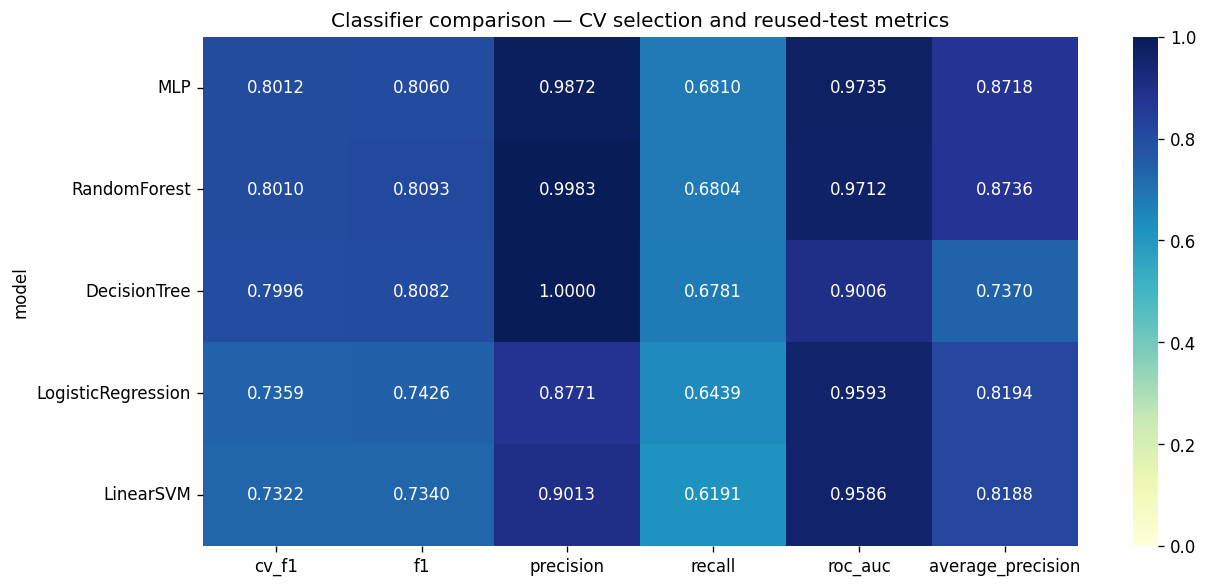

In [3]:
classifiers=comparison.query("kind == 'classifier'").sort_values('cv_f1',ascending=False)
winner=classifiers.iloc[0]
print('Recommended main classifier by CV F1:',winner['model'],'Member',int(winner['member']))
print('CV F1:',winner.cv_f1,'Test benchmark F1:',winner.f1)
metrics=classifiers.set_index('model')[['cv_f1','f1','precision','recall','roc_auc','average_precision']].astype(float)
plt.figure(figsize=(11,5));sns.heatmap(metrics,annot=True,fmt='.4f',vmin=0,vmax=1,cmap='YlGnBu');plt.title('Classifier comparison — CV selection and reused-test metrics');savefig(PROJECT_ROOT,'20_group_comparison_heatmap')
(PROJECT_ROOT/'results/modeling/recommended_model.json').write_text(json.dumps({'member':int(winner.member),'model':winner['model'],'criterion':'highest mean 3-fold CV F1','cv_f1':float(winner.cv_f1)},indent=2))
print('K-Means:',records[4])

## 03 · Next integration
Use the recommended fitted pipeline on eight raw inputs. Do not re-fit preprocessing on form values. No frontend is built in this package. Updated metrics supersede older guide screenshots; copy numbers from this run only.